In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn wordcloud nltk textblob -q


['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  \
count        7.400000e+02                               740.000000   
mean         7.204460e+06                                42.63

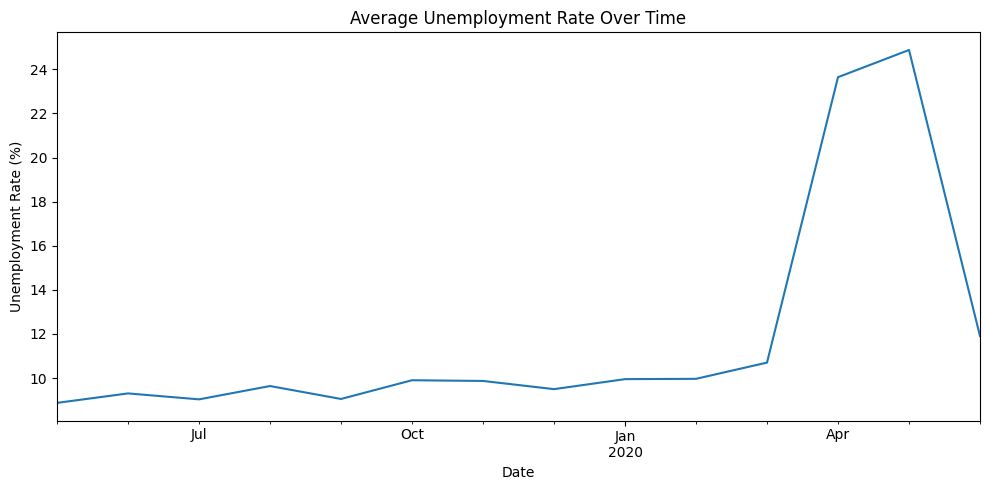

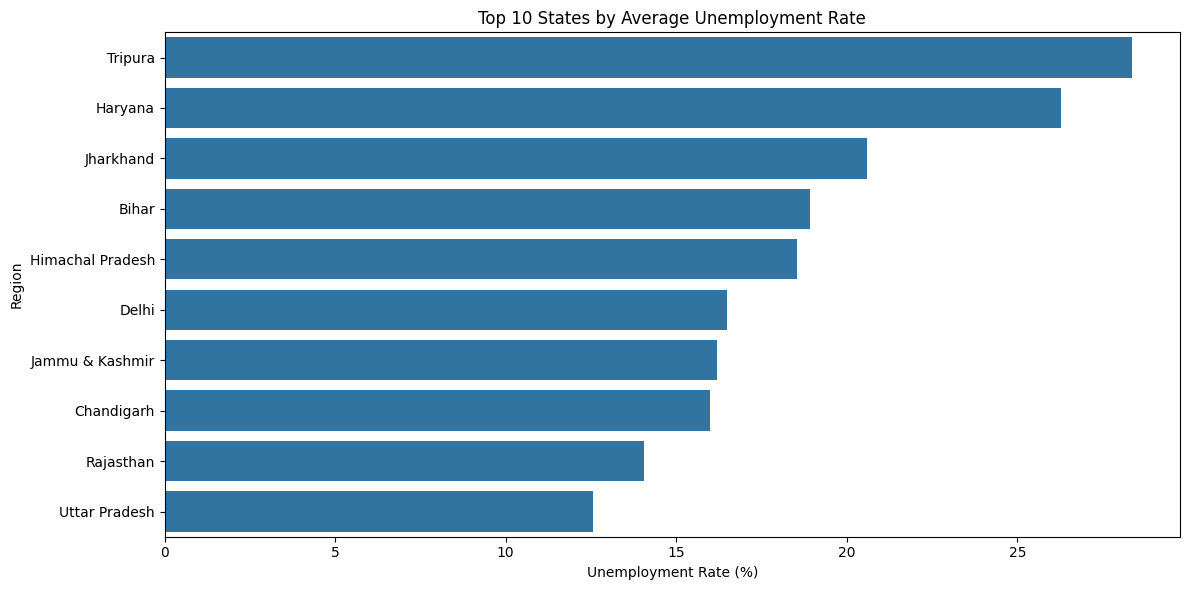

Pre-COVID avg unemployment: 9.509533582089553
COVID period avg unemployment: 17.774362745098042


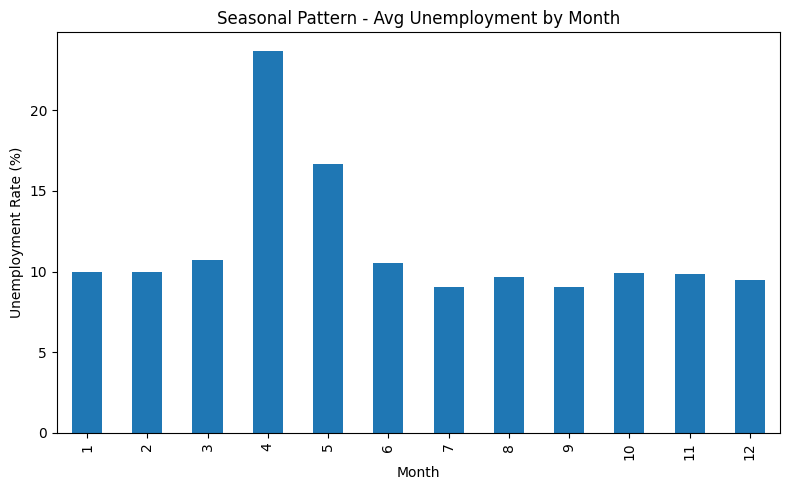


Insight: COVID lockdown months (Mar-Aug 2020) me unemployment rate significantly badha compared to pre-COVID — ye policy-makers ke liye important signal hai ki emergency employment schemes chalayi jaani chahiye during such crises.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv("Unemployment in India.csv")
df.columns = [c.strip() for c in df.columns]   # remove extra spaces in column names
print(df.columns.tolist())

# 2. Clean data
df.dropna(inplace=True)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print(df.describe())

# 3. Overall trend
plt.figure(figsize=(10,5))
df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().plot()
plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.savefig("unemployment_trend.png")
plt.show()

# 4. Top 10 states with highest unemployment
plt.figure(figsize=(12,6))
top_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_states.values, y=top_states.index)
plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.tight_layout()
plt.savefig("top_states_unemployment.png")
plt.show()

# 5. COVID-19 impact
pre_covid = df[df['Date'] < '2020-03-01']
covid_period = df[(df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-08-01')]
print("Pre-COVID avg unemployment:", pre_covid['Estimated Unemployment Rate (%)'].mean())
print("COVID period avg unemployment:", covid_period['Estimated Unemployment Rate (%)'].mean())

# 6. Seasonal pattern
monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()
plt.figure(figsize=(8,5))
monthly_avg.plot(kind='bar')
plt.title("Seasonal Pattern - Avg Unemployment by Month")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.savefig("seasonal_pattern.png")
plt.show()

# 7. Insight (for your report)
print("\nInsight: COVID lockdown months (Mar-Aug 2020) me unemployment rate significantly badha compared to pre-COVID — ye policy-makers ke liye important signal hai ki emergency employment schemes chalayi jaani chahiye during such crises.")